In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import unicodedata
import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks, initializers
from sklearn.metrics import (
    classification_report, precision_recall_curve,
    f1_score, confusion_matrix, ConfusionMatrixDisplay
)


In [2]:
# =========================================================
# 0. TEXT CLEANING (fixes UnicodeDecodeError: byte 0xc2 ...)
# =========================================================
def clean_text(s):
    """
    Python-side cleaning applied BEFORE data reaches TensorFlow.

    Root cause of the original error: scraped comment data contains
    characters such as the non-breaking space (\\xa0), ©, £, ¢ etc. These are
    encoded in UTF-8 as a two-byte sequence starting with 0xC2. Keras'
    default TextVectorization standardization ('lower_and_strip_punctuation')
    operates at the byte level and can split that two-byte sequence, leaving a
    dangling 0xC2 lead byte that fails to decode ->
    "UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc2 ... unexpected end of data".

    We normalize and strip non-ASCII so no multi-byte sequence survives into
    the byte-level standardizer.
    """
    if not isinstance(s, str):
        s = str(s)
    # Normalize compatibility forms (e.g. smart quotes, full-width chars)
    s = unicodedata.normalize("NFKC", s)
    # Drop any non-ASCII bytes (this removes the 0xC2-class characters)
    s = s.encode("ascii", "ignore").decode("ascii")
    # Collapse whitespace
    s = " ".join(s.split())
    return s if s else "missing_text"


def tf_standardize(input_data):
    """
    Custom standardization run INSIDE the TextVectorization layer.

    Acts as a second line of defense: lowercases, removes any remaining
    non-ASCII bytes, strips punctuation, and collapses whitespace - all on
    well-formed strings so the layer never produces a broken byte sequence.
    """
    lowercase = tf.strings.lower(input_data)
    ascii_only = tf.strings.regex_replace(lowercase, r"[^\x00-\x7F]+", " ")
    no_punct = tf.strings.regex_replace(ascii_only, r"[^a-z0-9\s]", " ")
    return tf.strings.regex_replace(no_punct, r"\s+", " ")


In [3]:
# %%
# =========================================================
# 1. MODELING PIPELINE (Keras Native)
# =========================================================
def build_bilstm_pipeline(train_texts, initial_bias=None, max_tokens=20000, output_sequence_length=150):
    """
    Constructs an end-to-end Keras model that handles raw text.
    """
    # 1. Text Vectorization Layer (Learns vocabulary from training data)
    vectorize_layer = layers.TextVectorization(
        max_tokens=max_tokens,
        output_mode='int',
        output_sequence_length=output_sequence_length,
        standardize=tf_standardize  # custom standardization (UTF-8 safe)
    )

    vectorize_layer.adapt(train_texts) # Build the vocabulary
    
    # 2. Set up the output bias for imbalanced data
    if initial_bias is not None:
        output_bias = initializers.Constant(initial_bias)
    else:
        output_bias = 'zeros'

    # 3. Model Architecture
    inputs = tf.keras.Input(shape=(1,), dtype=tf.string)
    x = vectorize_layer(inputs)
    # Embedding dimension can be tuned (e.g., 64, 128)
    x = layers.Embedding(input_dim=max_tokens, output_dim=128)(x) 
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    # Sigmoid output for binary classification
    outputs = layers.Dense(1, activation='sigmoid', bias_initializer=output_bias)(x)

    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[tf.keras.metrics.AUC(name='auc')]
    )
    
    return model



In [7]:
# %%
# =========================================================
# 2. EVALUATION FUNCTIONS (Untouched)
# =========================================================
def plot_threshold_curves(y_true, y_probs, dataset_name="Validation"):
    """Plots Precision, Recall, and F1 across all thresholds 0-1."""
    precision, recall, thresholds = precision_recall_curve(y_true, y_probs)
    
    # Calculate F1 safely
    f1_scores = np.divide(
        2 * (precision * recall), 
        (precision + recall), 
        out=np.zeros_like(precision), 
        where=(precision + recall) != 0
    )
    
    best_idx = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    
    plt.figure(figsize=(10, 5))
    plt.plot(thresholds, precision[:-1], label='Precision', color='#1f77b4', linestyle='--')
    plt.plot(thresholds, recall[:-1], label='Recall', color='#ff7f0e', linestyle='-.')
    plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='#2ca02c', linewidth=2.5)
    plt.axvline(best_threshold, color='red', linestyle=':', label=f'Best Threshold: {best_threshold:.2f}')
    
    plt.title(f'{dataset_name}: Metrics vs. Classification Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend(loc='lower left')
    plt.grid(alpha=0.3)
    plt.show()
    
    return best_threshold

def plot_dual_confusion_matrix(y_val, y_val_probs, y_test, y_test_probs, threshold=0.5):
    """Side-by-side CM for Validation and Test datasets using a custom threshold."""
    
    # Convert probabilities to hard labels based on the chosen threshold
    y_val_pred = (y_val_probs >= threshold).astype(int)
    y_test_pred = (y_test_probs >= threshold).astype(int)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    cm_val = confusion_matrix(y_val, y_val_pred)
    ConfusionMatrixDisplay(cm_val, display_labels=["Non-Toxic", "Toxic"]).plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title(f"Validation Confusion Matrix (Thresh={threshold:.2f})")
    
    cm_test = confusion_matrix(y_test, y_test_pred)
    ConfusionMatrixDisplay(cm_test, display_labels=["Non-Toxic", "Toxic"]).plot(ax=axes[1], cmap='Greens', colorbar=False)
    axes[1].set_title(f"Test Confusion Matrix (Thresh={threshold:.2f})")
    
    plt.tight_layout()
    plt.show()



In [18]:
def create_threshold_metrics_table(y_true, y_probs, step=0.05):
    """
    Generates a table of TP, FP, TN, FN across thresholds from 0 to 1.
    """
    thresholds = np.arange(0.0, 1.0 + step, step)
    results = []
    
    for t in thresholds:
        # Convert probabilities to hard labels based on current threshold t
        preds = (y_probs >= t).astype(int)
        
        # labels=[0,1] ensures it always returns a 2x2 matrix, even if preds are all 0 or all 1
        cm = confusion_matrix(y_true, preds, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        
        results.append({
            "Threshold": f"{t:.2f}",
            "TP": tp,
            "FP": fp,
            "TN": tn,
            "FN": fn
        })
        
    df_metrics = pd.DataFrame(results)
    return df_metrics




Loading data...
Negative samples: 1177428, Positive samples: 102261
Calculated Initial Bias: -2.4436
Class Weights: {0: 0.5434255852587164, 1: 6.2569747997770415}
🚀 Initializing Bi-LSTM Pipeline...
🚀 Training Bi-LSTM on GPU...
Epoch 1/30
4999/4999 [==============================] - 200s 39ms/step - loss: 0.3295 - auc: 0.9342 - val_loss: 0.4540 - val_auc: 0.9658
Epoch 2/30
4999/4999 [==============================] - 196s 39ms/step - loss: 0.2683 - auc: 0.9549 - val_loss: 0.4190 - val_auc: 0.9654
Epoch 3/30
4999/4999 [==============================] - 196s 39ms/step - loss: 0.2426 - auc: 0.9621 - val_loss: 0.3976 - val_auc: 0.9663
Epoch 4/30
4999/4999 [==============================] - 195s 39ms/step - loss: 0.2208 - auc: 0.9676 - val_loss: 0.3748 - val_auc: 0.9654
Epoch 5/30
4999/4999 [==============================] - 196s 39ms/step - loss: 0.2009 - auc: 0.9721 - val_loss: 0.3367 - val_auc: 0.9631
Epoch 6/30
4999/4999 [==============================] - 196s 39ms/step - loss: 0.1842 - 

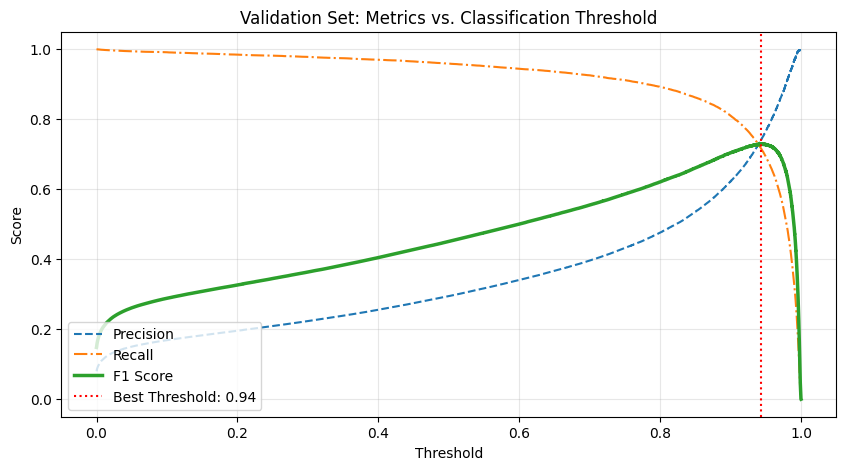

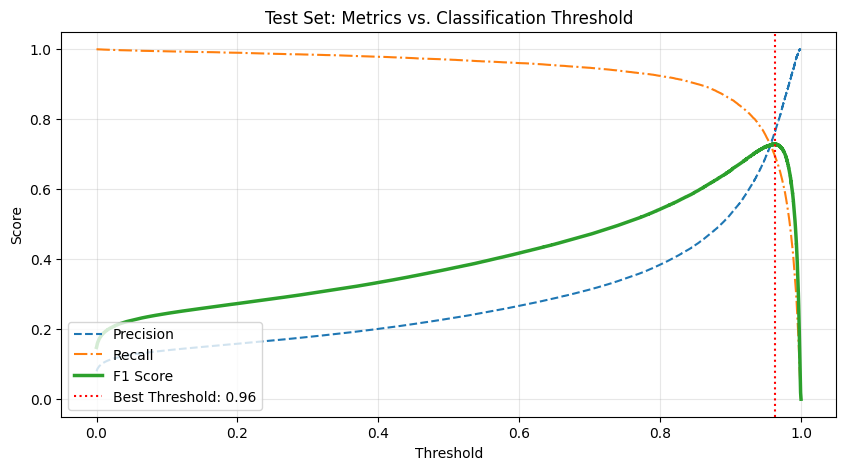


--- Confusion Matrices ---


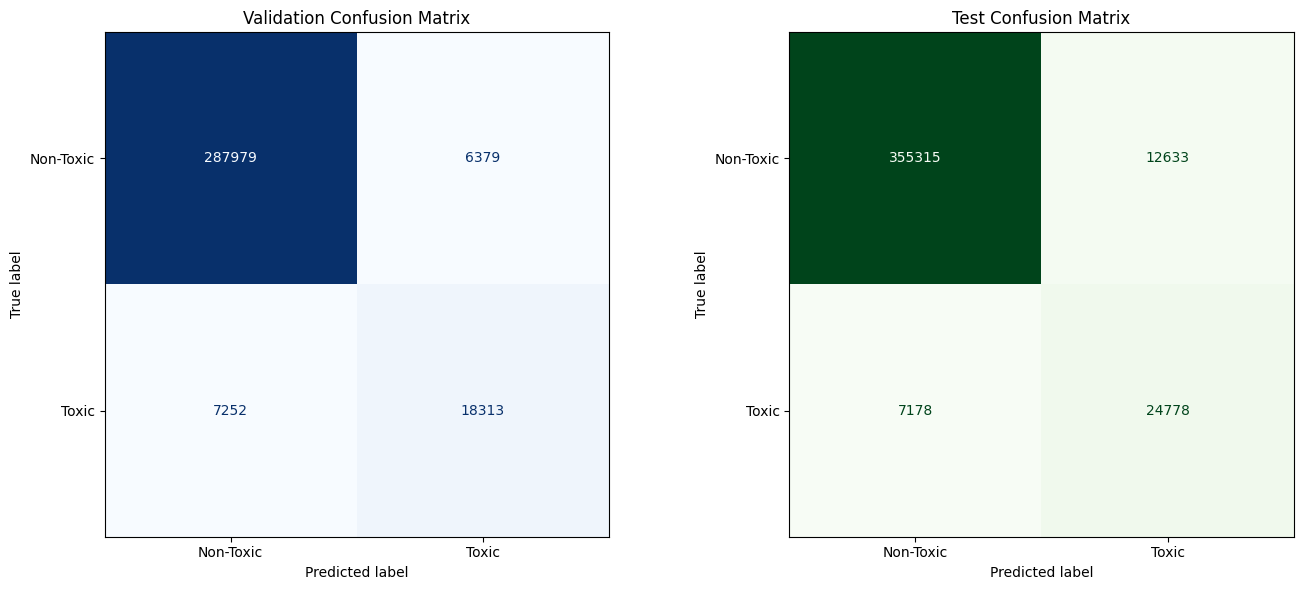

In [ ]:
# =========================================================
# 3. MAIN EXECUTION
# =========================================================
if __name__ == "__main__":
    # 1. Configuration
    TEXT_COL = 'comment_text'
    TARGET_COL = 'toxicity'
    
    # 2. Load Data 
    print("Loading data...")
    train_df = pd.read_csv("data/input/train_split.csv").fillna({TEXT_COL: "missing_text"})
    val_df = pd.read_csv("data/input/val_split.csv").fillna({TEXT_COL: "missing_text"})
    test_df = pd.read_csv("data/input/test_split.csv").fillna({TEXT_COL: "missing_text"})

    # Clean text Python-side: normalize and strip non-ASCII bytes so the
    # 0xC2-class characters can never leave a dangling UTF-8 lead byte.
    train_df[TEXT_COL] = train_df[TEXT_COL].map(clean_text)
    val_df[TEXT_COL] = val_df[TEXT_COL].map(clean_text)
    test_df[TEXT_COL] = test_df[TEXT_COL].map(clean_text)

    # Build text inputs as object-dtype arrays (each element stays a real Python str).
    X_train = train_df[TEXT_COL].to_numpy(dtype=object)
    X_val = val_df[TEXT_COL].to_numpy(dtype=object)
    X_test = test_df[TEXT_COL].to_numpy(dtype=object)
    
    # 3. Calculate Imbalance Parameters for Keras
    neg_count = (train_df[TARGET_COL] == 0).sum()
    pos_count = (train_df[TARGET_COL] == 1).sum()
    total = len(train_df)
    
    # Calculate initial bias (log odds)
    initial_bias = np.log([pos_count / neg_count])
    
    # Calculate class weights
    weight_for_0 = (1 / neg_count) * (total / 2.0)
    weight_for_1 = (1 / pos_count) * (total / 2.0)
    class_weight = {0: weight_for_0, 1: weight_for_1}
    
    print(f"Negative samples: {neg_count}, Positive samples: {pos_count}")
    print(f"Calculated Initial Bias: {initial_bias[0]:.4f}")
    print(f"Class Weights: {class_weight}")
    
    # 4. Build Model Pipeline
    print("🚀 Initializing Bi-LSTM Pipeline...")
    model = build_bilstm_pipeline(
        train_texts=X_train,
        initial_bias=initial_bias
    )
    
    # 5. Callbacks for Early Stopping (Restoring best weights like CatBoost)
    early_stopping = callbacks.EarlyStopping(
        monitor='val_auc', 
        verbose=1,
        patience=5,
        mode='max',
        restore_best_weights=True
    )
    
    # 6. Train Model
    print("🚀 Training Bi-LSTM on GPU...")
    history = model.fit(
        x=X_train,
        y=train_df[TARGET_COL].to_numpy(),
        batch_size=256,
        epochs=30,
        callbacks=[early_stopping],
        validation_data=(
            X_val,
            val_df[TARGET_COL].to_numpy()
        ),
        class_weight=class_weight
    )
    
    # 7. Predict Probabilities (Keras outputs arrays of shape (n, 1), so we flatten)
    val_probs = model.predict(X_val).flatten()
    test_probs = model.predict(X_test).flatten()
    
    # --- NEW: Print the Threshold Metrics Table ---
    print("\n--- Validation Set Metrics by Threshold ---")
    # Change step=0.05 to step=0.1 if you want fewer rows
    val_metrics_table = create_threshold_metrics_table(val_df[TARGET_COL], val_probs, step=0.05)
    # Using .to_string(index=False) prints a clean, nicely formatted table in the console
    print(val_metrics_table.to_string(index=False))
    
    # 8. Evaluate Thresholds
    print("\n--- Threshold Analysis ---")
    optimal_threshold = plot_threshold_curves(val_df[TARGET_COL], val_probs, "Validation Set")
    _ = plot_threshold_curves(test_df[TARGET_COL], test_probs, "Test Set")
    
    # 9. Plot Dual Confusion Matrices
    print("\n--- Confusion Matrices ---")
    plot_dual_confusion_matrix(
        y_val=val_df[TARGET_COL], y_val_probs=val_probs,
        y_test=test_df[TARGET_COL], y_test_probs=test_probs,
        threshold=optimal_threshold
    )
    
    
